# GP-KANの学習安定化方法調査: 比較用DeepGP

## 0.背景/目的
本notebookでは、DeepGPによる学習結果を評価する：

### モデル構成
- **ネットワーク構造**: 2層DeepGP(入力1次元 → 中間層 → 出力1次元)
- **誘導点数**: 各GPあたり10点

## 1.問題設定

真の関数: フーリエ級数
$$f(t) = \frac{4}{\pi} \sum_{n=1}^{N} \frac{1}{n} \sin(nt), \quad n = 1, 3, 5, \ldots, \quad t \in [0, 1]$$
※$N=15$

データ: 
- 合計1,000件: 学習700件/検証150件/評価150件
- tは$(-1,1)$から一様ランダムサンプリング

モデル:
- 2層のGPKAN: 入力1次元/中間層1次元/出力1次元
    - それぞれのGPを(<1層目のindex>,<2層目のindex>)形式で表すことにすると、GPKANは$(0,0),(1,0)$の2つのGPで構成



## 2.メイン処理
本ノートブックのメイン処理を実行する。実行順は以下の通り：

2-1.データセット作成

2-2.GPKANの学習

2-3.精度評価

2-4.学習中のカーネル行列ランク可視化

### 2-1.データセット作成

In [ ]:
# 初期設定: 必要なライブラリをインポートし、パスを設定
import os
import sys

sys.path.append("../../")
import japanize_matplotlib
import torch.utils.data
from lib import model as gplib
from lib import runner
from torch.utils.data import DataLoader

In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset


# Generate synthetic data with Fourier series function
def set_seed(seed=42):
    """完全な再現性のための乱数シード設定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def worker_init_fn(worker_id):
    """DataLoaderワーカープロセス用の乱数シード設定"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(42)  # 全体の乱数シード設定
num_samples = 1000

# Generate random input points t from [-1, 1]
t = np.random.uniform(-1, 1, num_samples)


# Compute target values: f(t) = (4/π) * Σ(1/n * sin(nt)) for odd n up to N=15
def fourier_series(t, N=15):
    result = np.zeros_like(t)
    for n in range(1, N + 1, 2):  # odd numbers only: 1, 3, 5, 7, 9, 11, 13, 15
        result += (1 / n) * np.sin(n * t)
    return (4 / np.pi) * result


targets = fourier_series(t, N=15)

# Reshape inputs (t is 1D, but we need it as 2D for compatibility)
inputs = t.reshape(-1, 1)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(inputs)
y_tensor = torch.FloatTensor(targets).reshape(-1, 1)

# Split data into train, validation, and test sets
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size : train_size + val_size]
y_val = y_tensor[train_size : train_size + val_size]

X_test = X_tensor[train_size + val_size :]
y_test = y_tensor[train_size + val_size :]

# データを昇順にソート（X_testとy_testを対応を保ちながら）
sorted_indices = torch.argsort(X_test.squeeze())
X_test = X_test[sorted_indices]
y_test = y_test[sorted_indices]

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create dataloaders
batch_size = 64

In [ ]:
# Create dataloaders with reproducible worker processes
generator = torch.Generator()
generator.manual_seed(42)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)

Train samples: 700
Validation samples: 150
Test samples: 150


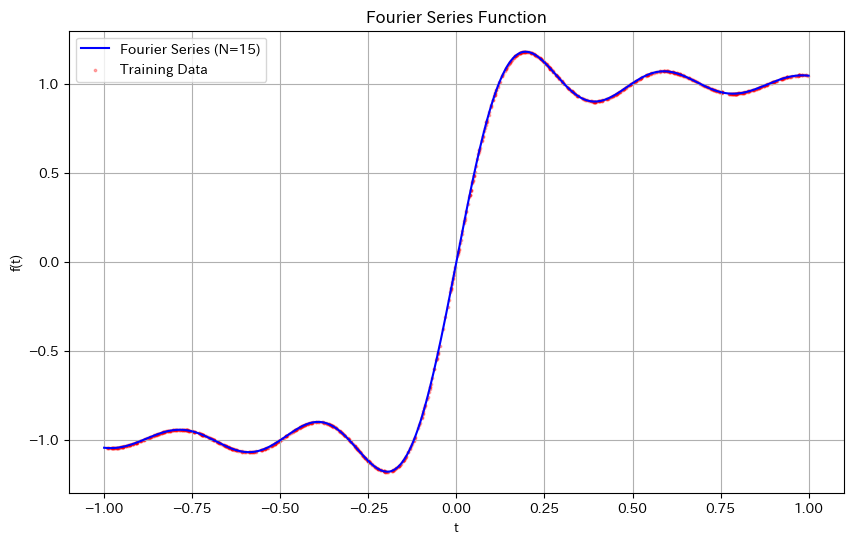

In [ ]:
# サンプル数確認
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Fourier級数関数のプロット
t_plot = np.linspace(-1, 1, 1000)
y_plot = fourier_series(t_plot, N=15)
plt.figure(figsize=(10, 6))
plt.plot(t_plot, y_plot, "b-", label="Fourier Series (N=15)")
plt.scatter(t, targets, alpha=0.3, s=3, c="red", label="Training Data")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Fourier Series Function")
plt.legend()
plt.grid(True)
plt.show()

### 2-2.モデル学習

In [ ]:
import gpytorch
import torch
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.means import ConstantMean, LinearMean
from gpytorch.mlls import DeepApproximateMLL
from gpytorch.models.deep_gps import DeepGP, DeepGPLayer
from gpytorch.variational import CholeskyVariationalDistribution, VariationalStrategy

# DeepGP model definition


class ToyDeepGPHiddenLayer(DeepGPLayer):
    def __init__(self, input_dims, output_dims, num_inducing=50, mean_type="constant"):
        if output_dims is None:
            inducing_points = torch.randn(num_inducing, input_dims)
            batch_shape = torch.Size([])
        else:
            inducing_points = torch.randn(output_dims, num_inducing, input_dims)
            batch_shape = torch.Size([output_dims])

        variational_distribution = CholeskyVariationalDistribution(
            num_inducing_points=num_inducing, batch_shape=batch_shape
        )

        variational_strategy = VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        super(ToyDeepGPHiddenLayer, self).__init__(
            variational_strategy, input_dims, output_dims
        )

        if mean_type == "constant":
            self.mean_module = ConstantMean(batch_shape=batch_shape)
        else:
            self.mean_module = LinearMean(input_dims)
        self.covar_module = ScaleKernel(
            RBFKernel(batch_shape=batch_shape, ard_num_dims=input_dims),
            batch_shape=batch_shape,
            ard_num_dims=None,
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return MultivariateNormal(mean_x, covar_x)

    def __call__(self, x, *other_inputs, **kwargs):
        """
        Overriding __call__ isn't strictly necessary, but it lets us add concatenation based skip connections
        easily. For example, hidden_layer2(hidden_layer1_outputs, inputs) will pass the concatenation of the first
        hidden layer's outputs and the input data to hidden_layer2.
        """
        if len(other_inputs):
            if isinstance(x, gpytorch.distributions.MultitaskMultivariateNormal):
                x = x.rsample()

            processed_inputs = [
                inp.unsqueeze(0).expand(
                    gpytorch.settings.num_likelihood_samples.value(), *inp.shape
                )
                for inp in other_inputs
            ]

            x = torch.cat([x] + processed_inputs, dim=-1)

        return super().__call__(x, are_samples=bool(len(other_inputs)))

In [ ]:
from gpytorch.likelihoods import GaussianLikelihood

# DeepGP model definition

num_hidden_dims = 1


class DeepGPModel(DeepGP):
    def __init__(self, train_x_shape):
        hidden_layer = ToyDeepGPHiddenLayer(
            input_dims=train_x_shape[-1],
            output_dims=num_hidden_dims,
            mean_type="linear",
        )

        last_layer = ToyDeepGPHiddenLayer(
            input_dims=hidden_layer.output_dims,
            output_dims=None,
            mean_type="constant",
        )

        super().__init__()

        self.hidden_layer = hidden_layer
        self.last_layer = last_layer
        self.likelihood = GaussianLikelihood()

    def forward(self, inputs):
        hidden_rep1 = self.hidden_layer(inputs)
        output = self.last_layer(hidden_rep1)
        return output

    def predict(self, test_loader):
        with torch.no_grad():
            mus = []
            variances = []
            lls = []
            for x_batch, y_batch in test_loader:
                preds = self.likelihood(self(x_batch))
                mus.append(preds.mean)
                variances.append(preds.variance)
                lls.append(self.likelihood.log_marginal(y_batch, self(x_batch)))

        return (
            torch.cat(mus, dim=-1),
            torch.cat(variances, dim=-1),
            torch.cat(lls, dim=-1),
        )

In [ ]:
import torch
import tqdm.notebook
from gpytorch.mlls import VariationalELBO

# this is for running the notebook in our testing framework
num_epochs = 200
num_samples = train_size // batch_size

model = DeepGPModel(X_train.shape)

optimizer = torch.optim.Adam(
    [
        {"params": model.parameters()},
    ],
    lr=0.001,
)
mll = DeepApproximateMLL(VariationalELBO(model.likelihood, model, X_train.shape[-2]))

epochs_iter = tqdm.notebook.tqdm(range(num_epochs), desc="Epoch")
for i in epochs_iter:
    # Within each iteration, we will go over each minibatch of data
    minibatch_iter = tqdm.notebook.tqdm(train_dataloader, desc="Minibatch", leave=False)
    for x_batch, y_batch in minibatch_iter:
        # Get the actual batch size (may be smaller for the last batch)
        actual_batch_size = x_batch.size(0)

        with gpytorch.settings.num_likelihood_samples(actual_batch_size):
            optimizer.zero_grad()
            output = model(x_batch)
            loss = -mll(output, y_batch)
            loss.backward()
            optimizer.step()

            minibatch_iter.set_postfix(loss=loss.item())

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

...

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
# # 現在の設定
# optimizer = torch.optim.Adam([{"params": model.parameters()}], lr=0.001)

# # 推奨調整範囲
# learning_rates = [5.0, 1.0, 0.1, 0.05, 0.01, 0.005, 0.001]

# # 最適化
# for lr in learning_rates:
#     optimizer = torch.optim.Adam([{"params": model.parameters()}], lr=lr)
#     print(f"Testing learning rate: {lr}")
#     # 少数エポックで学習して損失の変化を確認
#     for epoch in range(20):  # 少数エポックで試す
#         epoch_loss = 0
#         for x_batch, y_batch in train_dataloader:
#             actual_batch_size = x_batch.size(0)
#             with gpytorch.settings.num_likelihood_samples(actual_batch_size):
#                 optimizer.zero_grad()
#                 output = model(x_batch)
#                 loss = -mll(output, y_batch)
#                 loss.backward()
#                 optimizer.step()
#                 epoch_loss += loss.item()
#         print(f"  Epoch {epoch+1}, Loss: {epoch_loss/len(train_dataloader):.4f}")

# Inducing Pointsと予測分布の可視化

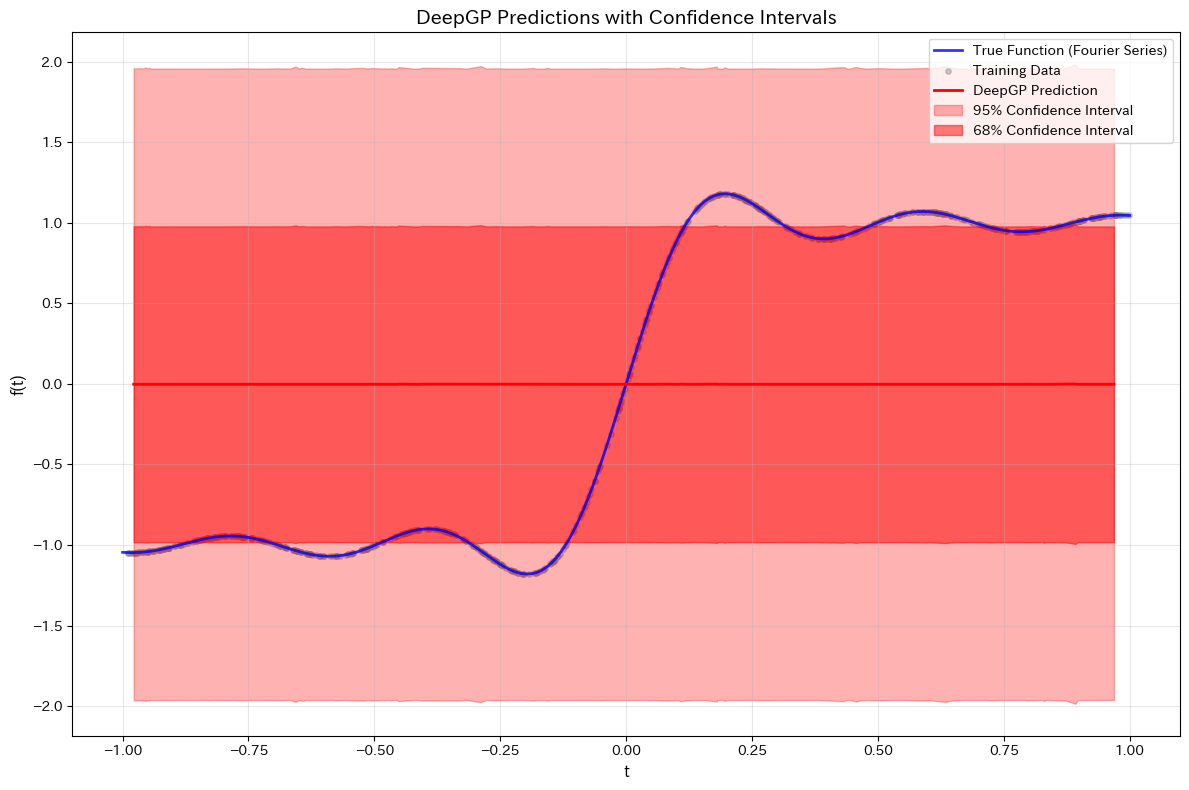

Test RMSE: 0.9960
Test MSE: 0.9921


In [ ]:
# モデルを評価モードに設定
model.eval()

# テストデータで予測を実行
with torch.no_grad():
    # サンプリング数を1に設定して予測を実行
    with gpytorch.settings.num_likelihood_samples(1):
        test_predictions = model(X_test)
        predictive_dist = model.likelihood(test_predictions)

        # 平均と分散を取得し、適切な次元に変換
        mean_predictions = predictive_dist.mean.squeeze()  # (150,)の形状に
        variance_predictions = predictive_dist.variance.squeeze()  # (150,)の形状に
        std_predictions = torch.sqrt(variance_predictions)

# 可視化
plt.figure(figsize=(12, 8))

# 真の関数をプロット
t_plot = np.linspace(-1, 1, 1000)
y_plot = fourier_series(t_plot, N=15)
plt.plot(
    t_plot, y_plot, "b-", linewidth=2, label="True Function (Fourier Series)", alpha=0.8
)

# 訓練データをプロット
plt.scatter(
    X_train.numpy(), y_train.numpy(), alpha=0.4, s=15, c="gray", label="Training Data"
)

# 予測結果をプロット
X_test_np = X_test.squeeze().numpy()
mean_np = mean_predictions.numpy()
std_np = std_predictions.numpy()

plt.plot(X_test_np, mean_np, "r-", linewidth=2, label="DeepGP Prediction")

# 信頼区間をプロット (±2σ)
plt.fill_between(
    X_test_np,
    mean_np - 2 * std_np,
    mean_np + 2 * std_np,
    alpha=0.3,
    color="red",
    label="95% Confidence Interval",
)

# 信頼区間をプロット (±1σ)
plt.fill_between(
    X_test_np,
    mean_np - std_np,
    mean_np + std_np,
    alpha=0.5,
    color="red",
    label="68% Confidence Interval",
)

plt.xlabel("t", fontsize=12)
plt.ylabel("f(t)", fontsize=12)
plt.title("DeepGP Predictions with Confidence Intervals", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 予測精度の評価
mse = torch.mean((mean_predictions - y_test.squeeze()) ** 2)
rmse = torch.sqrt(mse)
print(f"Test RMSE: {rmse.item():.4f}")
print(f"Test MSE: {mse.item():.4f}")